# 06 · Z-Test, T-Test and Chi-Square Test

In notebook 05 we learned the logic of testing. Now we run real tests from start to finish, always with the same six steps.

**What you will learn here**

1. One-sample **z-test** (mean, σ known or large sample)
2. How to get the p-value from a z value by hand
3. One-sample **t-test** (mean, σ unknown, small sample)
4. **Z-test for a proportion**
5. **Chi-square goodness-of-fit test** (categories)

Each test: textbook example by hand first, then Python, then a real dataset.

**Datasets:** restaurant **tips** (`data/tips.csv`) and **Titanic** passengers (`data/titanic.csv`). See notebooks 01 and 04 for column descriptions.

> **Colour guide:** $\color{red}{\text{red}}$ marks a rejected null hypothesis, a warning or a wrong reading. $\color{green}{\text{green}}$ marks a null hypothesis we fail to reject, a passed check or a correct reading.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.weightstats import ztest
from statsmodels.stats.proportion import proportions_ztest

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREEN = "#1baf7a"

tips = pd.read_csv("../data/tips.csv")
tips["tip_percent"] = tips["tip"] / tips["total_bill"] * 100
titanic = pd.read_csv("../data/titanic.csv")

### Which test for which situation?

| Question about... | Population σ known? | Sample size | Test |
|---|---|---|---|
| a mean | yes | any (n ≥ 30 is the usual textbook rule) | z-test |
| a mean | no | small | t-test |
| a mean | no | large | t-test (z-test gives almost the same answer) |
| a proportion (share of yes) | n/a | large enough | z-test for a proportion |
| counts in categories | n/a | expected count ≥ 5 per category | chi-square |

In practice the t-test is the safe default for means, because σ is almost never known.

Read more: [Student's t-test (Wikipedia)](https://en.wikipedia.org/wiki/Student%27s_t-test)

---
## 1. One-sample z-test

> **Theory.** Compares a sample mean with a known population value $\mu_0$.

**Why do we need it?** "Is this machine filling bottles with the right amount?", "Did this group score differently from the national average?"

**Formula**

$$z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$$

| Symbol | Meaning |
|---|---|
| $\bar{x}$ | sample mean |
| $\mu_0$ | the value from H₀ |
| $\sigma / \sqrt{n}$ | standard error of the mean |

Note the √n. A single person's z-score (notebook 03) uses σ. A **sample mean** wobbles less than a single value, by a factor of √n. Notebook 08 (central limit theorem) shows why.

### Example 1: a medicine and IQ

Population IQ: μ = 100, σ = 15. A sample of 30 people who took a new medicine has an average IQ of 140. Did the medicine affect IQ? Use α = 0.05.

**By hand**

1. H₀: μ = 100
2. H₁: μ ≠ 100 (two-tailed, "any effect")
3. α = 0.05 → critical values ±1.96
4. Decision rule: reject H₀ if z < −1.96 or z > 1.96
5. $z = \dfrac{140 - 100}{15 / \sqrt{30}} = \dfrac{40}{2.739} = 14.61$
6. 14.61 > 1.96 → $\color{red}{\textbf{reject } H_0}$. The medicine changed IQ (upwards, since z is positive).

In [2]:
def one_sample_z(x_bar, mu_0, sigma, n):
    return (x_bar - mu_0) / (sigma / np.sqrt(n))

z = one_sample_z(x_bar=140, mu_0=100, sigma=15, n=30)
print(f"z = {z:.2f}")
print("Reject H0" if abs(z) > 1.96 else "Fail to reject H0")

z = 14.61
Reject H0


### Example 2: getting the p-value by hand

Average weight in a town is 168 lbs with σ = 3.9. A nutritionist weighs 36 people and gets a mean of 169.5. Is the true mean different? α = 0.05.

**By hand**

1. H₀: μ = 168, H₁: μ ≠ 168
2. $z = \dfrac{169.5 - 168}{3.9 / \sqrt{36}} = \dfrac{1.5}{0.65} = 2.31$
3. z-table at 2.31 → 0.98956, so one tail = 1 − 0.98956 = 0.01044
4. Two-tailed p-value = 2 × 0.01044 = **0.021**
5. 0.0209 < 0.05 → $\color{red}{\textbf{reject } H_0}$

In [3]:
z = one_sample_z(169.5, 168, 3.9, 36)
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
one_tail = 1 - stats.norm.cdf(abs(z))
p_value = 2 * one_tail

print(f"z = {z:.3f}, one tail = {one_tail:.4f}, two-tailed p-value = {p_value:.4f}")

z = 2.308, one tail = 0.0105, two-tailed p-value = 0.0210


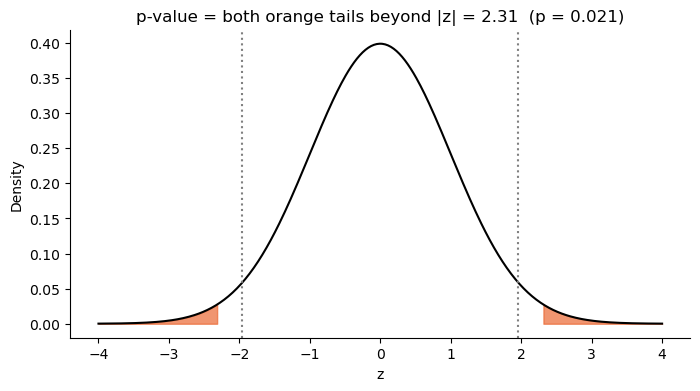

In [4]:
x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots()
ax.plot(x, stats.norm.pdf(x), color="black")
for side in [x >= abs(z), x <= -abs(z)]:
    ax.fill_between(x[side], stats.norm.pdf(x[side]), color=ORANGE, alpha=0.7)
ax.axvline(1.96, color="grey", linestyle=":")
ax.axvline(-1.96, color="grey", linestyle=":")
ax.set_title(f"p-value = both orange tails beyond |z| = {abs(z):.2f}  (p = {p_value:.3f})")
ax.set_xlabel("z")
ax.set_ylabel("Density")
plt.show()

The two orange tails together are the p-value. Dotted lines are the ±1.96 critical values. Our z is beyond them, so both ways of deciding (critical value or p-value) agree.

### Real data: do customers tip 15%?

A common rule of thumb in the US was to tip 15% of the bill. Is the average tip percentage at this restaurant different from 15%?

We don't know the population σ, but with n = 244 the z-test using the sample sd is fine (`statsmodels.ztest` does exactly this).

1. H₀: mean tip % = 15
2. H₁: mean tip % ≠ 15
3. α = 0.05

In [5]:
tip_pct = tips["tip_percent"]

z_by_hand = (tip_pct.mean() - 15) / (tip_pct.std() / np.sqrt(len(tip_pct)))
p_by_hand = 2 * (1 - stats.norm.cdf(abs(z_by_hand)))

# docs: https://www.statsmodels.org/stable/generated/statsmodels.stats.weightstats.ztest.html
z_stat, p_value = ztest(tip_pct, value=15)

print(f"sample mean = {tip_pct.mean():.2f}%, n = {len(tip_pct)}")
print(f"by hand  : z = {z_by_hand:.3f}, p = {p_by_hand:.4f}")
print(f"ztest()  : z = {z_stat:.3f}, p = {p_value:.4f}")

sample mean = 16.08%, n = 244
by hand  : z = 2.763, p = 0.0057
ztest()  : z = 2.763, p = 0.0057


> **Conclusion:** p = 0.006 < 0.05 → $\color{red}{\text{reject } H_0}$. Customers at this restaurant tip a bit more than 15% on average (about 16.1%). Statistically clear, but in practical terms the difference is about 1 percentage point, roughly 20 cents on a 20 dollar bill.

---
## 2. One-sample t-test

> **Theory.** Same question as the z-test (is the mean equal to $\mu_0$?), but we use the sample sd $s$ because σ is unknown. The statistic follows a t distribution with n − 1 degrees of freedom.

**Formula**

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}, \qquad df = n - 1$$

### Example: bike batteries (one-tailed)

A company says its batteries last **2 years or more**. An engineer thinks it's less. He tests 10 batteries: mean 1.8 years, s = 0.15. Use 99% confidence (α = 0.01).

**By hand**

1. H₀: μ ≥ 2
2. H₁: μ < 2 (left-tailed, the engineer only cares about "less")
3. α = 0.01, df = 10 − 1 = 9 → t-table (one tail, 0.01) → critical value **−2.821**
4. Reject H₀ if t < −2.821
5. $t = \dfrac{1.8 - 2}{0.15 / \sqrt{10}} = \dfrac{-0.2}{0.0474} = -4.216$
6. −4.216 < −2.821 → $\color{red}{\textbf{reject } H_0}$. The batteries last less than 2 years.

In [6]:
x_bar, mu_0, s, n = 1.8, 2, 0.15, 10

t_stat = (x_bar - mu_0) / (s / np.sqrt(n))
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html
t_critical = stats.t.ppf(0.01, df=n - 1)
p_value = stats.t.cdf(t_stat, df=n - 1)   # left tail only

print(f"t = {t_stat:.3f}, critical value = {t_critical:.3f}, one-tailed p = {p_value:.5f}")

t = -4.216, critical value = -2.821, one-tailed p = 0.00113


### Real data: Friday tips

Only 19 bills were on a Friday. Is the average Friday tip percentage different from 15%? With such a small sample the t-test is the right tool.

In [7]:
friday = tips.loc[tips["day"] == "Fri", "tip_percent"]

n = len(friday)
t_by_hand = (friday.mean() - 15) / (friday.std() / np.sqrt(n))
p_by_hand = 2 * (1 - stats.t.cdf(abs(t_by_hand), df=n - 1))

# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html
result = stats.ttest_1samp(friday, popmean=15)

print(f"n = {n}, mean = {friday.mean():.2f}%, sd = {friday.std():.2f}")
print(f"by hand        : t = {t_by_hand:.3f}, p = {p_by_hand:.4f}")
print(f"ttest_1samp()  : t = {result.statistic:.3f}, p = {result.pvalue:.4f}")

n = 19, mean = 16.99%, sd = 4.77
by hand        : t = 1.821, p = 0.0853
ttest_1samp()  : t = 1.821, p = 0.0853


**Conclusion:** p = 0.085 > 0.05 → we $\color{green}{\textbf{fail to reject } H_0}$.

This is a good lesson. The Friday average (17.0%) is actually **further** from 15% than the overall average (16.1%), but the test is not significant. Why? Only 19 bills, so the standard error is big and the test has low power. Not significant does **not** mean "Friday tips are 15%". It means "19 bills are not enough to tell".

---
## 3. Z-test for a proportion

> **Theory.** Used when the data is yes/no and we test the **share of yes**.

**Formula**

$$z = \frac{\hat{p} - p_0}{\sqrt{\dfrac{p_0 (1 - p_0)}{n}}}$$

| Symbol | Meaning |
|---|---|
| $\hat{p}$ | sample proportion ("p hat") = yes / n |
| $p_0$ | proportion under H₀ |
| $\sqrt{p_0(1-p_0)/n}$ | standard error of a proportion |

### Example: phone ownership

A company believes 70% of residents in a town own a smartphone. A survey of 200 people finds 130 owners. Is the true share different? α = 0.05.

**By hand**

1. H₀: p = 0.70, H₁: p ≠ 0.70
2. $\hat{p} = 130/200 = 0.65$
3. Standard error = √(0.7 × 0.3 / 200) = √0.00105 = 0.0324
4. z = (0.65 − 0.70) / 0.0324 = **−1.54**
5. p-value = 2 × (1 − 0.9382) = **0.124**
6. 0.124 > 0.05 → $\color{green}{\textbf{fail to reject } H_0}$. The survey is consistent with 70%.

In [8]:
count, n, p0 = 130, 200, 0.70

p_hat = count / n
se = np.sqrt(p0 * (1 - p0) / n)
z = (p_hat - p0) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"by hand: z = {z:.3f}, p = {p_value:.4f}")

# docs: https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html
z_sm, p_sm = proportions_ztest(count, n, value=p0, prop_var=p0)
print(f"statsmodels: z = {z_sm:.3f}, p = {p_sm:.4f}")

by hand: z = -1.543, p = 0.1228
statsmodels: z = -1.543, p = 0.1228


`prop_var=p0` tells statsmodels to use $p_0$ in the standard error, like the textbook formula. Without it, statsmodels uses $\hat{p}$, which gives a slightly different z.

### Real data: is our Titanic file a fair picture of everyone on board?

A commonly quoted figure is that about **32%** of the roughly 2,224 people on board survived. In our file, 342 of 891 people survived (38.4%). Is the difference just sampling noise?

1. H₀: p = 0.32
2. H₁: p ≠ 0.32
3. α = 0.05

In [9]:
survivors = titanic["survived"].sum()
n = len(titanic)

z_stat, p_value = proportions_ztest(survivors, n, value=0.32, prop_var=0.32)
print(f"sample proportion = {survivors / n:.3f}")
print(f"z = {z_stat:.2f}, p = {p_value:.6f}")

sample proportion = 0.384
z = 4.08, p = 0.000044


**Conclusion:** p < 0.001 → $\color{red}{\text{reject } H_0}$. Our file has clearly more survivors than the ship as a whole.

**But why?** This is where thinking beats calculating. The "2,224 people on board" includes the **crew**, and our file only contains **passengers**. Crew members had a lower survival rate than passengers, so a passengers-only file will naturally show a higher rate. The test is correct, and what it really found is that the sample doesn't come from the population we compared it to. A significant result can point to a sampling problem rather than a real effect, so always ask *where the data came from* (remember convenience sampling in notebook 01).

---
## 4. Chi-square goodness-of-fit test

> **Theory.** The chi-square (χ²) test works with **counts in categories**. The goodness-of-fit version checks whether observed counts match an expected distribution.

It is a **non-parametric** test: it doesn't assume the data is normal.

**Why do we need it?** "Are customers spread evenly across days?", "Did the age mix of a town change since the last census?", "Did our A/B test split users 50/50 as planned?"

**Formula**

$$\chi^2 = \sum \frac{(O - E)^2}{E}, \qquad df = k - 1$$

| Symbol | Meaning |
|---|---|
| $O$ | observed count in a category |
| $E$ | expected count under H₀ |
| $k$ | number of categories |

Every category adds a bit: big gaps between observed and expected add a lot. Dividing by $E$ makes a gap of 10 matter more in a small category than in a big one.

Read more: [Pearson's chi-squared test (Wikipedia)](https://en.wikipedia.org/wiki/Pearson%27s_chi-squared_test)

### Example 1: has the age mix of a town changed?

Ten years ago: under 18 = 20%, 18 to 35 = 30%, over 35 = 50%. Today a sample of 500 people gives 121, 288, 91. α = 0.05.

**By hand**

| | < 18 | 18 to 35 | > 35 |
|---|---|---|---|
| Observed O | 121 | 288 | 91 |
| Expected E = 500 × share | 100 | 150 | 250 |
| (O − E)² / E | 441/100 = 4.41 | 19044/150 = 126.96 | 25281/250 = 101.12 |

χ² = 4.41 + 126.96 + 101.12 = **232.49**

df = 3 − 1 = 2 → chi-square table at 0.05 → critical value **5.991**

232.49 > 5.991 → $\color{red}{\textbf{reject } H_0}$. The age distribution has changed.

In [10]:
observed = np.array([121, 288, 91])
expected = 500 * np.array([0.20, 0.30, 0.50])

chi2_by_hand = ((observed - expected) ** 2 / expected).sum()
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html
critical = stats.chi2.ppf(0.95, df=len(observed) - 1)

print(f"chi-square by hand = {chi2_by_hand:.2f}, critical value = {critical:.3f}")
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chisquare.html
print(stats.chisquare(observed, f_exp=expected))

chi-square by hand = 232.49, critical value = 5.991
Power_divergenceResult(statistic=232.494, pvalue=3.270162712012095e-51)


### Example 2: school absences

A principal expects absences to be spread evenly over 5 days. 100 teachers report the day with most absences: Mon 23, Tue 16, Wed 14, Thu 19, Fri 28. Expected: 20 each.

**By hand:** χ² = (9 + 16 + 36 + 1 + 64) / 20 = 126 / 20 = **6.3**. df = 4 → critical value 9.488. 6.3 < 9.488 → $\color{green}{\textbf{fail to reject } H_0}$.

In [11]:
observed = [23, 16, 14, 19, 28]
print(stats.chisquare(observed))
print("critical value:", round(stats.chi2.ppf(0.95, df=4), 3))

Power_divergenceResult(statistic=6.3, pvalue=0.1778363264982168)
critical value: 9.488


Friday looks high (28), but with only 100 answers this pattern could easily be random.

### Real data: are the bills spread evenly over the four days?

In [12]:
day_order = ["Thur", "Fri", "Sat", "Sun"]
observed = tips["day"].value_counts().reindex(day_order)
expected = pd.Series(len(tips) / 4, index=day_order)

table = pd.DataFrame({"observed": observed, "expected": expected})
table["(O-E)^2/E"] = ((table["observed"] - table["expected"]) ** 2 / table["expected"]).round(2)
table

,observed,expected,(O-E)^2/E
Thur,62,61.0,0.02
Fri,19,61.0,28.92
Sat,87,61.0,11.08
Sun,76,61.0,3.69


In [13]:
chi2_stat, p_value = stats.chisquare(observed, f_exp=expected)
print(f"chi-square = {chi2_stat:.2f}, df = 3, p = {p_value:.2e}")

chi-square = 43.70, df = 3, p = 1.74e-09


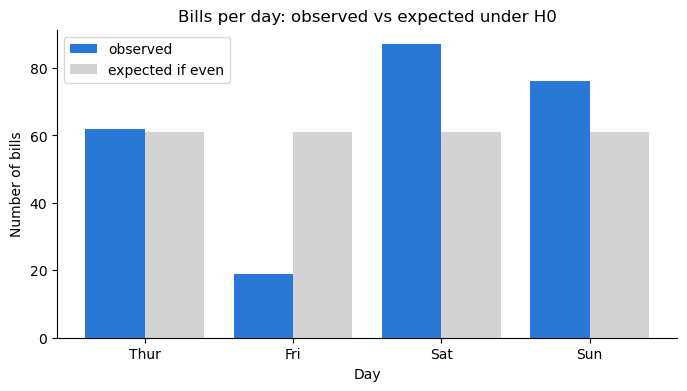

In [14]:
fig, ax = plt.subplots()
positions = np.arange(len(day_order))
ax.bar(positions - 0.2, table["observed"], width=0.4, color=BLUE, label="observed")
ax.bar(positions + 0.2, table["expected"], width=0.4, color="lightgrey", label="expected if even")
ax.set_xticks(positions)
ax.set_xticklabels(day_order)
ax.set_title("Bills per day: observed vs expected under H0")
ax.set_xlabel("Day")
ax.set_ylabel("Number of bills")
ax.legend()
plt.show()

**Conclusion:** p is tiny → $\color{red}{\text{reject } H_0}$. The bills are not spread evenly. Friday contributes most of the χ² value (only 19 bills where 61 were expected). The restaurant may simply be closed on some Fridays, or the waiter worked fewer Friday shifts. The test tells us *that* the counts differ, not *why*.

---
## Summary

| Test | Data | Statistic | Typical question |
|---|---|---|---|
| One-sample z | mean, σ known / large n | $(\bar{x} - \mu_0)/(\sigma/\sqrt{n})$ | Is the average tip 15%? |
| One-sample t | mean, σ unknown | $(\bar{x} - \mu_0)/(s/\sqrt{n})$, df = n − 1 | Do batteries last 2 years? |
| Proportion z | yes / no | $(\hat{p} - p_0)/\sqrt{p_0(1-p_0)/n}$ | Is the survival rate 32%? |
| Chi-square GOF | counts in categories | $\sum (O-E)^2/E$, df = k − 1 | Are days evenly busy? |

Lessons from the real data:

- Significant does not mean important (tips: 16.1% vs 15%).
- Not significant does not mean "no effect" (Friday: only 19 bills).
- A significant result can come from a sampling problem (Titanic: passengers vs everyone on board).

The **two-sample** versions (comparing two groups), paired tests, chi-square test of independence and ANOVA for many groups are in the experimentation folder: `02_experimentation/03_other_statistical_tests.ipynb`.

## What's next

In **07 · Covariance and Correlation** we measure how two variables move together, with covariance, Pearson and Spearman correlation.

## References and further reading

- [OpenIntro Statistics](https://www.openintro.org/book/os/) (free textbook), chapters 6 (proportions, chi-square) and 7 (means, t-tests)
- [Z-test, Wikipedia](https://en.wikipedia.org/wiki/Z-test) · [Student's t-test, Wikipedia](https://en.wikipedia.org/wiki/Student%27s_t-test)
- [statsmodels `ztest`](https://www.statsmodels.org/stable/generated/statsmodels.stats.weightstats.ztest.html) · [statsmodels `proportions_ztest`](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html)
- [scipy `ttest_1samp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html) · [scipy `chisquare`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chisquare.html)